In [1]:
STUDENT_NAME = "Aadithyan Thandayamparambil Suresh Babu"
ROLL_NUMBER = "2528713"
COURSE = "MBAV 443M - Statistical Modeling and AI-Driven Analytics"

print(f"Student Name: {STUDENT_NAME}")
print(f"Roll Number: {ROLL_NUMBER}")
print(f"Course: {COURSE}")

Student Name: Aadithyan Thandayamparambil Suresh Babu
Roll Number: 2528713
Course: MBAV 443M - Statistical Modeling and AI-Driven Analytics


In [2]:
# Import the libraries required for data handling, statistics, and visualization.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_FILE = Path("A1_2528713_ThandayamparambilSureshBabu_data.csv")
FIGURE_FILE = Path("A1_2528713_ThandayamparambilSureshBabu_channel_spending.png")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the dataset from the same folder as this notebook.
df = pd.read_csv(DATA_FILE)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 440
Columns: 8


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
# Confirm column types, missing values, duplicates, and impossible negative spending.
spending_cols = [
    "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"
]

quality_check = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique(),
})

duplicate_rows = int(df.duplicated().sum())
negative_values = int((df[spending_cols] < 0).sum().sum())

display(quality_check)
print(f"Duplicate rows: {duplicate_rows}")
print(f"Negative spending values: {negative_values}")

,Data type,Missing values,Unique values
Channel,int64,0,2
Region,int64,0,3
Fresh,int64,0,433
Milk,int64,0,421
Grocery,int64,0,430
Frozen,int64,0,426
Detergents_Paper,int64,0,417
Delicassen,int64,0,403


Duplicate rows: 0
Negative spending values: 0


In [5]:
# Add readable group labels while preserving the original coded columns.
# Common interpretation of the UCI Wholesale Customers dataset:
# Channel 1 = Horeca (hotel/restaurant/cafe), Channel 2 = Retail.
# Region 1 = Lisbon, Region 2 = Oporto, Region 3 = Other.
channel_map = {1: "Horeca", 2: "Retail"}
region_map = {1: "Lisbon", 2: "Oporto", 3: "Other"}

df["Channel_Name"] = df["Channel"].map(channel_map)
df["Region_Name"] = df["Region"].map(region_map)

customer_mix = pd.crosstab(
    df["Region_Name"],
    df["Channel_Name"],
    margins=True,
    margins_name="Total"
)

display(customer_mix)

Channel_Name,Horeca,Retail,Total
Region_Name,,,
Lisbon,59,18,77
Oporto,28,19,47
Other,211,105,316
Total,298,142,440


In [6]:
# Calculate useful descriptive measures for every product category.
summary = df[spending_cols].agg(
    ["count", "mean", "median", "std", "min", "max", "skew"]
).T
summary["CV (%)"] = (summary["std"] / summary["mean"]) * 100
summary = summary[
    ["count", "mean", "median", "std", "min", "max", "skew", "CV (%)"]
]

display(summary)

,count,mean,median,std,min,max,skew,CV (%)
Fresh,440.00,"12,000.30","8,504.00","12,647.33",3.00,"112,151.00",2.56,105.39
Milk,440.00,"5,796.27","3,627.00","7,380.38",55.00,"73,498.00",4.05,127.33
Grocery,440.00,"7,951.28","4,755.50","9,503.16",3.00,"92,780.00",3.59,119.52
Frozen,440.00,"3,071.93","1,526.00","4,854.67",25.00,"60,869.00",5.91,158.03
Detergents_Paper,440.00,"2,881.49",816.50,"4,767.85",3.00,"40,827.00",3.63,165.46
Delicassen,440.00,"1,524.87",965.50,"2,820.11",3.00,"47,943.00",11.15,184.94


In [7]:
# Compare typical (median) annual spending across the two customer channels.
channel_medians = (
    df.groupby("Channel_Name", observed=True)[spending_cols]
      .median()
      .T
)
channel_medians["Retail / Horeca ratio"] = (
    channel_medians["Retail"] / channel_medians["Horeca"]
)

display(channel_medians.sort_values("Retail / Horeca ratio", ascending=False))

Channel_Name,Horeca,Retail,Retail / Horeca ratio
Detergents_Paper,385.50,"5,614.50",14.56
Grocery,"2,684.00","12,390.00",4.62
Milk,"2,157.00","7,812.00",3.62
Delicassen,821.00,"1,350.00",1.64
Fresh,"9,581.50","5,993.50",0.63
Frozen,"2,057.50","1,081.00",0.53


In [8]:
def benjamini_hochberg(p_values):
    # Return FDR-adjusted p-values in the original order.
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = ranked * len(p) / np.arange(1, len(p) + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = adjusted_ranked
    return adjusted


# Spearman correlation is appropriate because the spending distributions are skewed.
spearman_corr = df[spending_cols].corr(method="spearman")
display(spearman_corr)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.00,-0.08,-0.12,0.38,-0.20,0.24
Milk,-0.08,1.00,0.77,-0.09,0.68,0.37
Grocery,-0.12,0.77,1.00,-0.17,0.80,0.30
Frozen,0.38,-0.09,-0.17,1.00,-0.21,0.23
Detergents_Paper,-0.20,0.68,0.80,-0.21,1.00,0.18
Delicassen,0.24,0.37,0.30,0.23,0.18,1.00


In [9]:
# Mann-Whitney tests compare spending distributions between Horeca and Retail.
channel_results = []
horeca = df.loc[df["Channel_Name"] == "Horeca"]
retail = df.loc[df["Channel_Name"] == "Retail"]

for column in spending_cols:
    u_stat, p_value = stats.mannwhitneyu(
        retail[column], horeca[column], alternative="two-sided"
    )
    # Rank-biserial correlation: positive values mean Retail tends to be higher.
    effect = (2 * u_stat) / (len(retail) * len(horeca)) - 1
    channel_results.append({
        "Category": column,
        "Horeca median": horeca[column].median(),
        "Retail median": retail[column].median(),
        "U statistic": u_stat,
        "Raw p-value": p_value,
        "Rank-biserial effect": effect,
    })

channel_tests = pd.DataFrame(channel_results)
channel_tests["Adjusted p-value"] = benjamini_hochberg(
    channel_tests["Raw p-value"]
)
channel_tests["Significant at 5%"] = channel_tests["Adjusted p-value"] < 0.05
channel_tests = channel_tests.sort_values("Adjusted p-value")

display(channel_tests)

,Category,Horeca median,Retail median,U statistic,Raw p-value,Rank-biserial effect,Adjusted p-value,Significant at 5%
4,Detergents_Paper,385.50,"5,614.50","40,649.00",0.00,0.92,0.00,True
2,Grocery,"2,684.00","12,390.00","39,681.00",0.00,0.88,0.00,True
1,Milk,"2,157.00","7,812.00","37,193.50",0.00,0.76,0.00,True
3,Frozen,"2,057.50","1,081.00","14,984.00",0.00,-0.29,0.00,True
0,Fresh,"9,581.50","5,993.50","16,493.00",0.00,-0.22,0.00,True
5,Delicassen,821.00,"1,350.00","25,467.50",0.00,0.20,0.00,True


In [10]:
# Kruskal-Wallis tests compare the three regions without assuming normality.
region_results = []

for column in spending_cols:
    groups = [
        group[column].to_numpy()
        for _, group in df.groupby("Region_Name", observed=True)
    ]
    h_stat, p_value = stats.kruskal(*groups)
    region_results.append({
        "Category": column,
        "H statistic": h_stat,
        "Raw p-value": p_value,
    })

region_tests = pd.DataFrame(region_results)
region_tests["Adjusted p-value"] = benjamini_hochberg(
    region_tests["Raw p-value"]
)
region_tests["Significant at 5%"] = region_tests["Adjusted p-value"] < 0.05
region_tests = region_tests.sort_values("Adjusted p-value")

display(region_tests)

,Category,H statistic,Raw p-value,Adjusted p-value,Significant at 5%
3,Frozen,2.86,0.24,0.72,False
2,Grocery,3.20,0.20,0.72,False
1,Milk,1.46,0.48,0.88,False
0,Fresh,1.07,0.59,0.88,False
4,Detergents_Paper,0.45,0.80,0.89,False
5,Delicassen,0.23,0.89,0.89,False


In [11]:
# IQR flags are diagnostic: they identify unusually high/low observations,
# not errors that should automatically be removed.
outlier_rows = []

for column in spending_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_rows.append({
        "Category": column,
        "Lower fence": lower,
        "Upper fence": upper,
        "Flagged observations": int(count),
        "Flagged (%)": 100 * count / len(df),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "Flagged (%)", ascending=False
)
display(outlier_summary)

,Category,Lower fence,Upper fence,Flagged observations,Flagged (%)
3,Frozen,"-3,475.75","7,772.25",43,9.77
4,Detergents_Paper,"-5,241.12","9,419.88",30,6.82
1,Milk,"-6,952.88","15,676.12",28,6.36
5,Delicassen,"-1,709.75","3,938.25",27,6.14
2,Grocery,"-10,601.12","23,409.88",24,5.45
0,Fresh,"-17,581.25","37,642.75",20,4.55


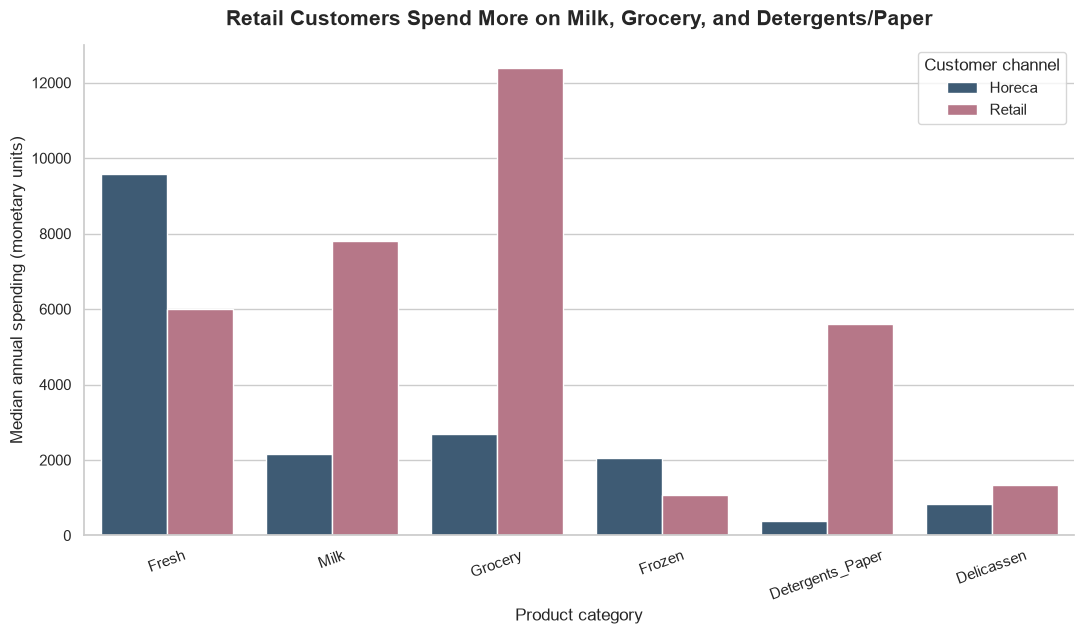

Saved report-ready figure: C:\Users\AADITHYAN\Documents\Codex\2026-06-15\files-mentioned-by-the-user-wholesale\outputs\A1_2528713_ThandayamparambilSureshBabu_channel_spending.png


In [12]:
# Final report figure: median annual spending by channel.
plot_data = (
    df.groupby("Channel_Name", observed=True)[spending_cols]
      .median()
      .T
      .reset_index()
      .melt(
          id_vars="index",
          var_name="Channel",
          value_name="Median annual spending"
      )
      .rename(columns={"index": "Product category"})
)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=plot_data,
    x="Product category",
    y="Median annual spending",
    hue="Channel",
    palette={"Horeca": "#355C7D", "Retail": "#C06C84"},
    ax=ax,
)
ax.set_title(
    "Retail Customers Spend More on Milk, Grocery, and Detergents/Paper",
    fontsize=15,
    weight="bold",
    pad=14,
)
ax.set_xlabel("Product category")
ax.set_ylabel("Median annual spending (monetary units)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Customer channel", frameon=True)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved report-ready figure: {FIGURE_FILE.resolve()}")

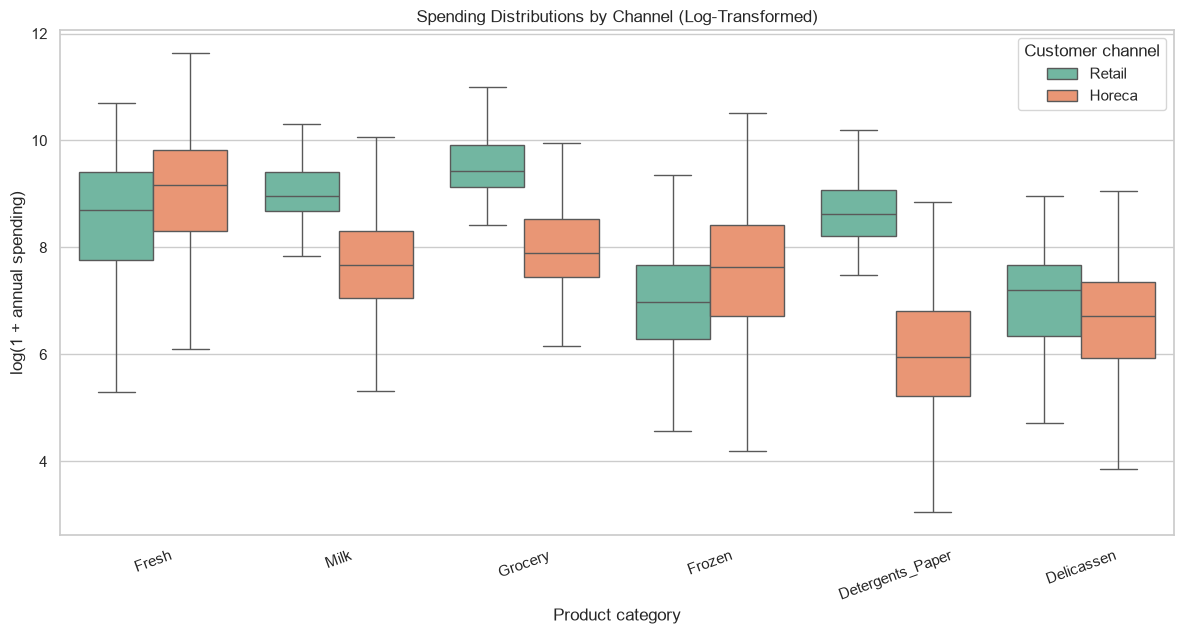

In [13]:
# Notebook-only exploratory plot: log-scaled distributions reveal the full range.
long_spending = df.melt(
    id_vars=["Channel_Name"],
    value_vars=spending_cols,
    var_name="Product category",
    value_name="Annual spending",
)
long_spending["log1p spending"] = np.log1p(long_spending["Annual spending"])

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.boxplot(
    data=long_spending,
    x="Product category",
    y="log1p spending",
    hue="Channel_Name",
    showfliers=False,
    palette="Set2",
    ax=ax,
)
ax.set_title("Spending Distributions by Channel (Log-Transformed)")
ax.set_xlabel("Product category")
ax.set_ylabel("log(1 + annual spending)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Customer channel")
fig.tight_layout()
plt.show()

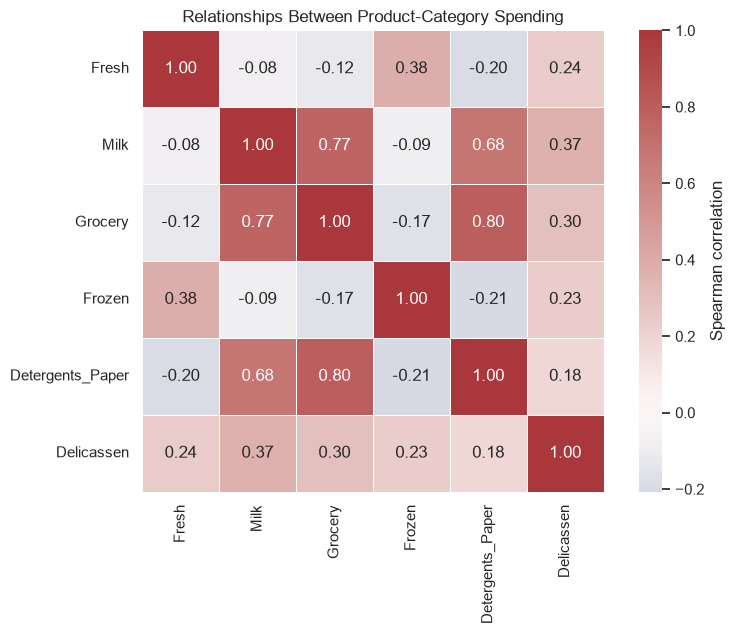

In [14]:
# Notebook-only correlation heatmap.
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Relationships Between Product-Category Spending")
fig.tight_layout()
plt.show()

In [15]:
# Generate a compact, reproducible set of findings from the computed results.
strong_pairs = (
    spearman_corr.where(
        np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

top_pair = strong_pairs.index[0]
top_corr = strong_pairs.iloc[0]
significant_channel = channel_tests.loc[
    channel_tests["Significant at 5%"], "Category"
].tolist()
significant_region = region_tests.loc[
    region_tests["Significant at 5%"], "Category"
].tolist()

print(
    f"Strongest spending relationship: {top_pair[0]} and {top_pair[1]} "
    f"(Spearman rho = {top_corr:.3f})."
)
print(
    "Categories with a statistically significant channel difference: "
    + (", ".join(significant_channel) if significant_channel else "None")
)
print(
    "Categories with a statistically significant regional difference: "
    + (", ".join(significant_region) if significant_region else "None")
)

Strongest spending relationship: Grocery and Detergents_Paper (Spearman rho = 0.801).
Categories with a statistically significant channel difference: Detergents_Paper, Grocery, Milk, Frozen, Fresh, Delicassen
Categories with a statistically significant regional difference: None


In [16]:
# Final reproducibility checks required before submission.
assert df.shape == (440, 10), "Unexpected dataset dimensions after adding labels."
assert df[spending_cols].isna().sum().sum() == 0, "Missing spending values found."
assert (df[spending_cols] >= 0).all().all(), "Negative spending values found."
assert FIGURE_FILE.exists(), "The report-ready figure was not saved."
assert FIGURE_FILE.stat().st_size > 10_000, "The saved figure appears incomplete."

print("All final reproducibility checks passed.")
print(f"Notebook dataset: {DATA_FILE.resolve()}")
print(f"Report-ready figure: {FIGURE_FILE.resolve()}")

All final reproducibility checks passed.
Notebook dataset: C:\Users\AADITHYAN\Documents\Codex\2026-06-15\files-mentioned-by-the-user-wholesale\outputs\A1_2528713_ThandayamparambilSureshBabu_data.csv
Report-ready figure: C:\Users\AADITHYAN\Documents\Codex\2026-06-15\files-mentioned-by-the-user-wholesale\outputs\A1_2528713_ThandayamparambilSureshBabu_channel_spending.png
